In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("processed/tomato_daily.csv")

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [5]:
print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "→", df["date"].max())

print("\nMissing prices:", df["price"].isna().sum())

Dataset shape: (1849, 2)

Date range:
2020-01-01 00:00:00 → 2025-10-29 00:00:00

Missing prices: 0


In [6]:
print(df["price"].describe())

count    1849.000000
mean     1835.437804
std      1018.371825
min       520.000000
25%      1150.000000
50%      1525.000000
75%      2300.000000
max      7450.000000
Name: price, dtype: float64


In [7]:
full_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

In [8]:
df_full = (
    df.set_index("date")
      .reindex(full_dates)
      .rename_axis("date")
      .reset_index()
)

In [9]:
print("\nTotal calendar days:", len(df_full))
print("Observed days:", df_full["price"].notna().sum())
print("Missing days:", df_full["price"].isna().sum())


Total calendar days: 2129
Observed days: 1849
Missing days: 280


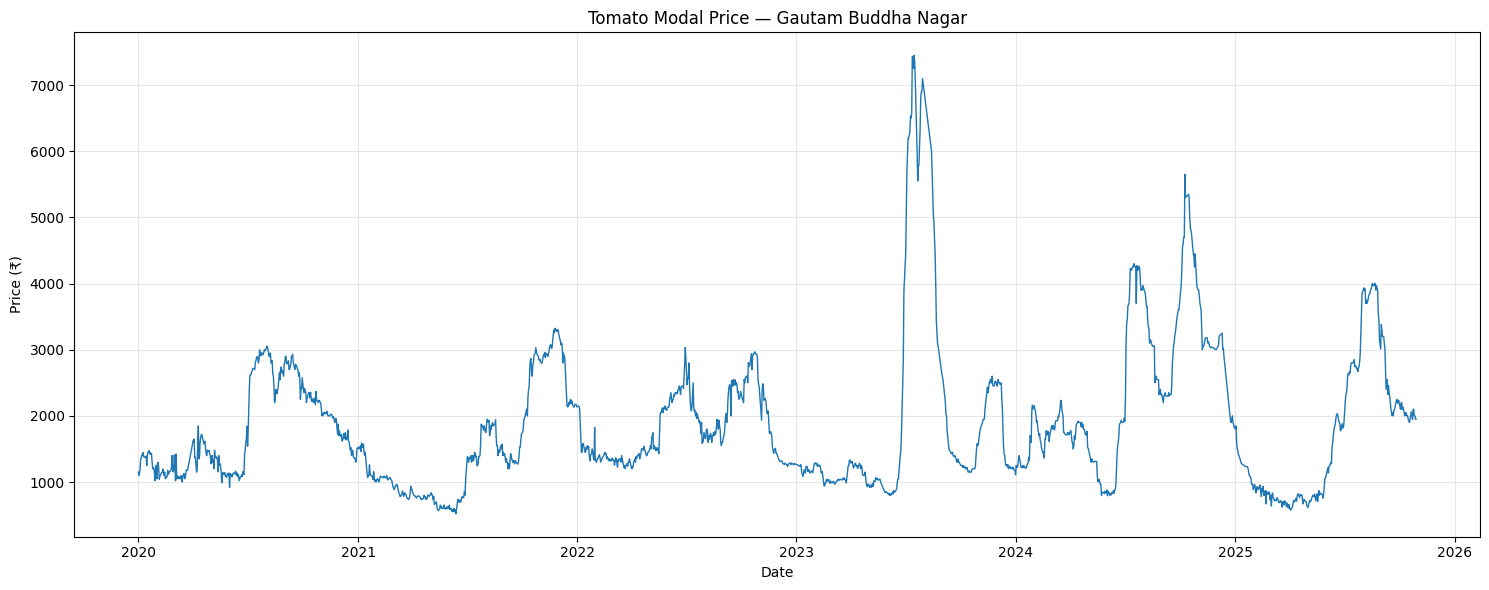

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(
    df["date"],
    df["price"],
    linewidth=1
)
plt.title("Tomato Modal Price — Gautam Buddha Nagar")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
df_full["rolling_30"] = (
    df_full["price"]
    .rolling(30, min_periods=10)
    .mean()
)

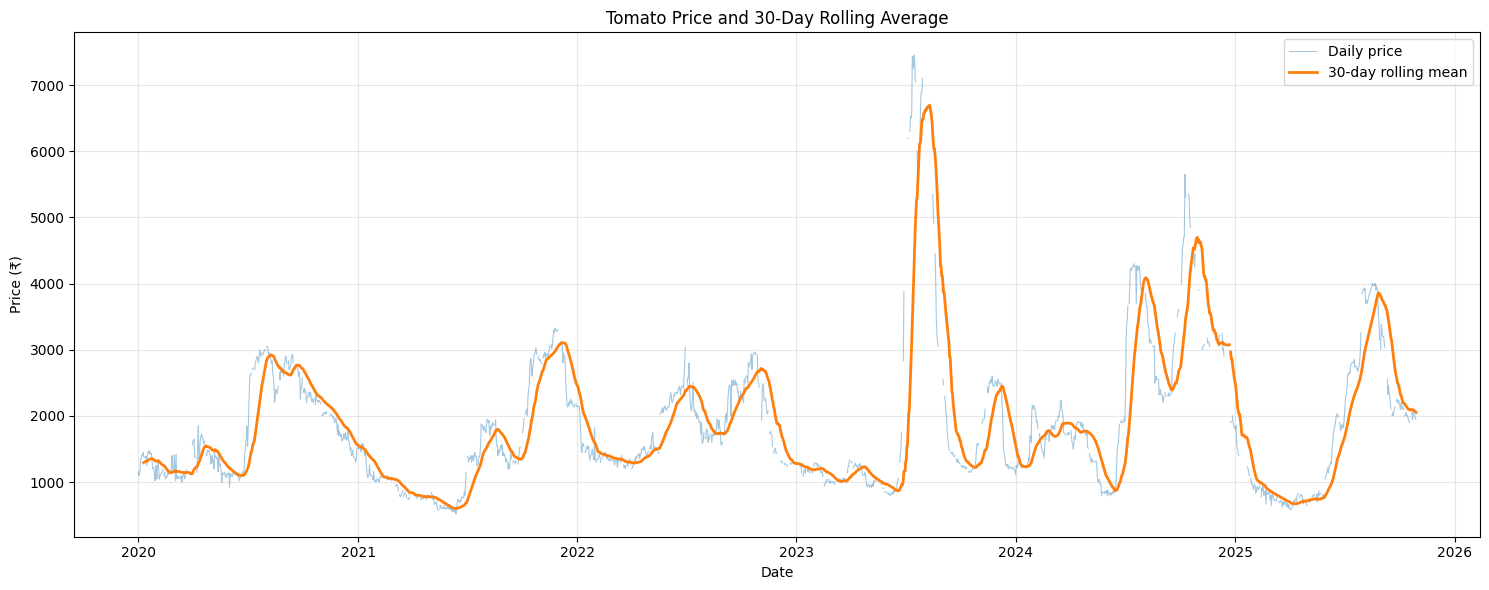

In [12]:
plt.figure(figsize=(15, 6))
plt.plot(
    df_full["date"],
    df_full["price"],
    alpha=0.4,
    linewidth=0.8,
    label="Daily price"
)
plt.plot(
    df_full["date"],
    df_full["rolling_30"],
    linewidth=2,
    label="30-day rolling mean"
)
plt.title("Tomato Price and 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
monthly = (
    df.set_index("date")["price"]
      .resample("ME")
      .mean()
)


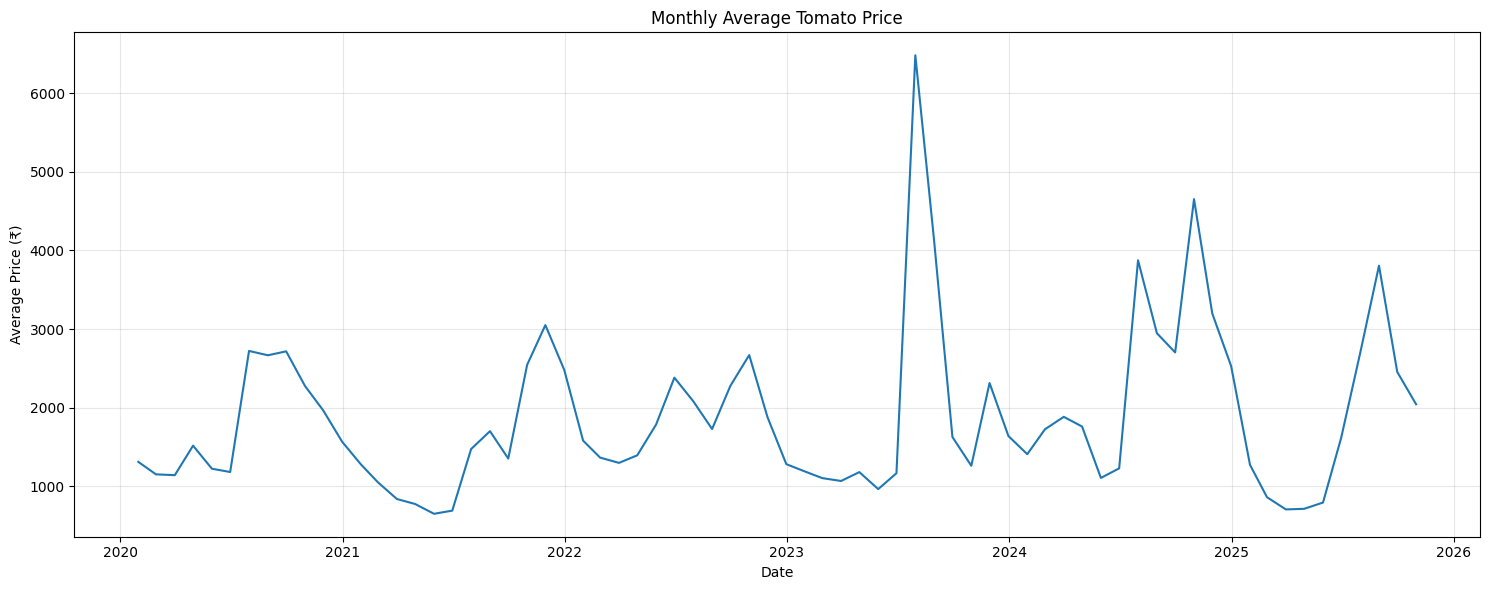

In [14]:
plt.figure(figsize=(15, 6))
plt.plot(
    monthly.index,
    monthly.values,
    linewidth=1.5
)
plt.title("Monthly Average Tomato Price")
plt.xlabel("Date")
plt.ylabel("Average Price (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
yearly = (
    df.set_index("date")["price"]
      .resample("YE")
      .mean()
)

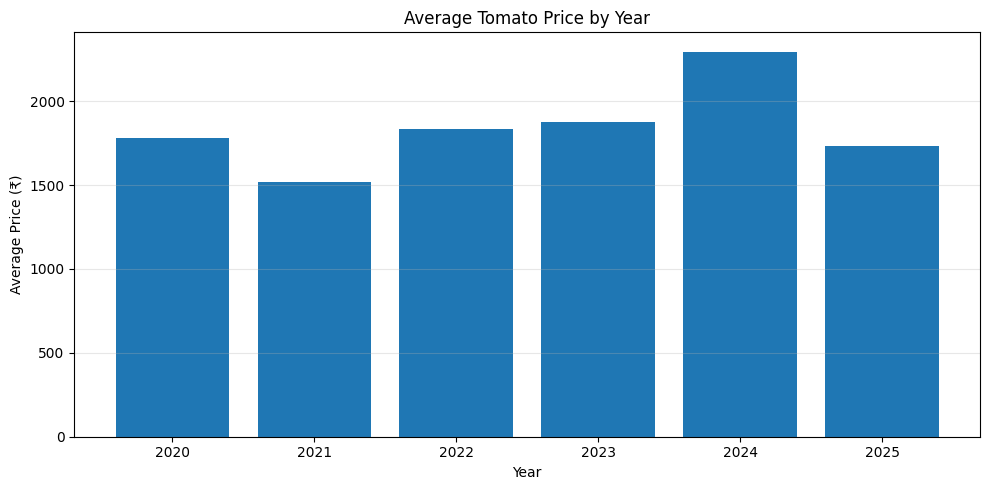

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(
    yearly.index.year.astype(str),
    yearly.values
)
plt.title("Average Tomato Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price (₹)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
df["month"] = df["date"].dt.month

In [18]:
monthly_seasonality = (
    df.groupby("month")["price"]
      .mean()
)

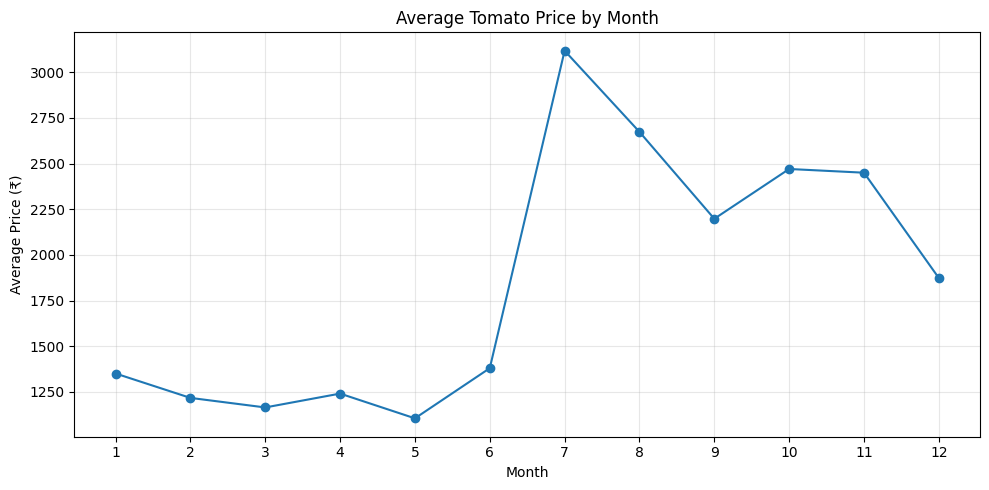

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Tomato Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price (₹)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

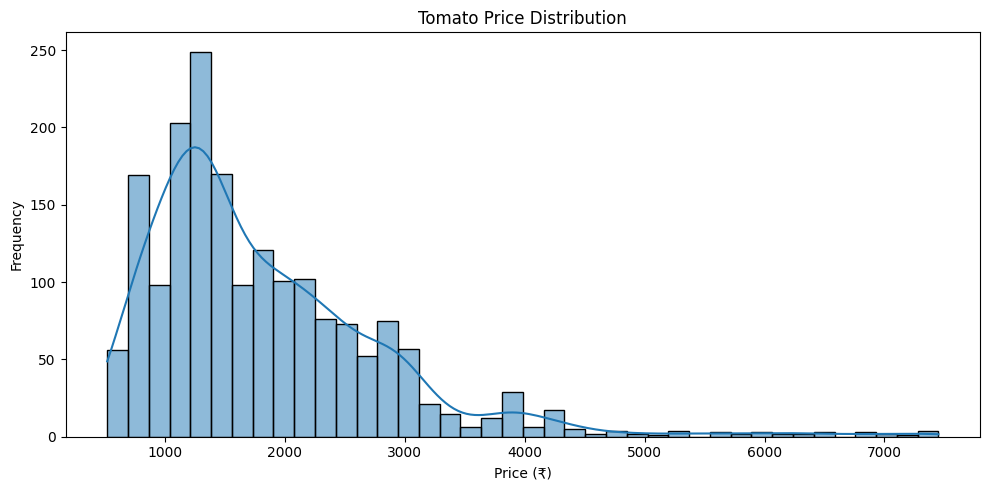

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=40,
    kde=True
)

plt.title("Tomato Price Distribution")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

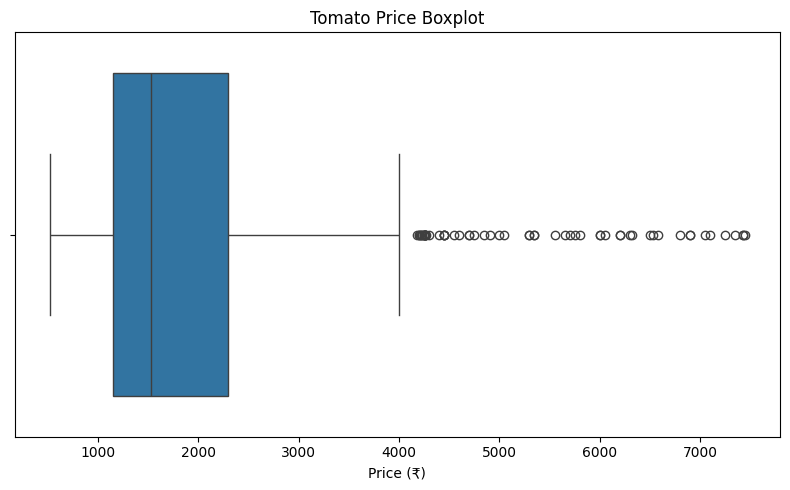

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df["price"]
)

plt.title("Tomato Price Boxplot")
plt.xlabel("Price (₹)")

plt.tight_layout()
plt.show()

In [22]:
df["year"] = df["date"].dt.year


In [23]:
heatmap_data = (
    df.groupby(["year", "month"])["price"]
      .mean()
      .unstack()
)


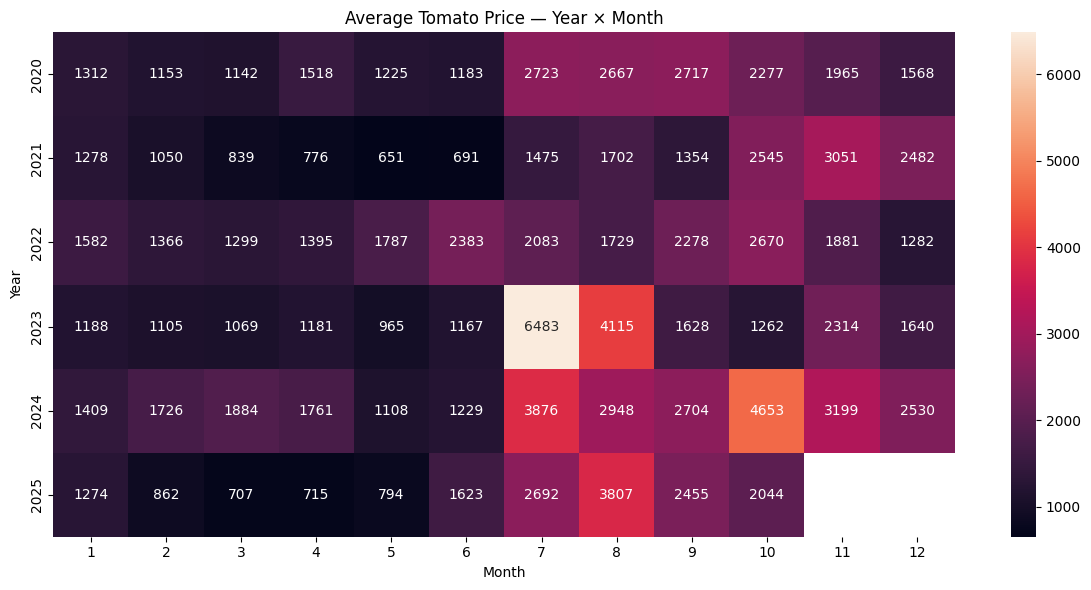

In [24]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Average Tomato Price — Year × Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [25]:
df["price_change"] = df["price"].diff()

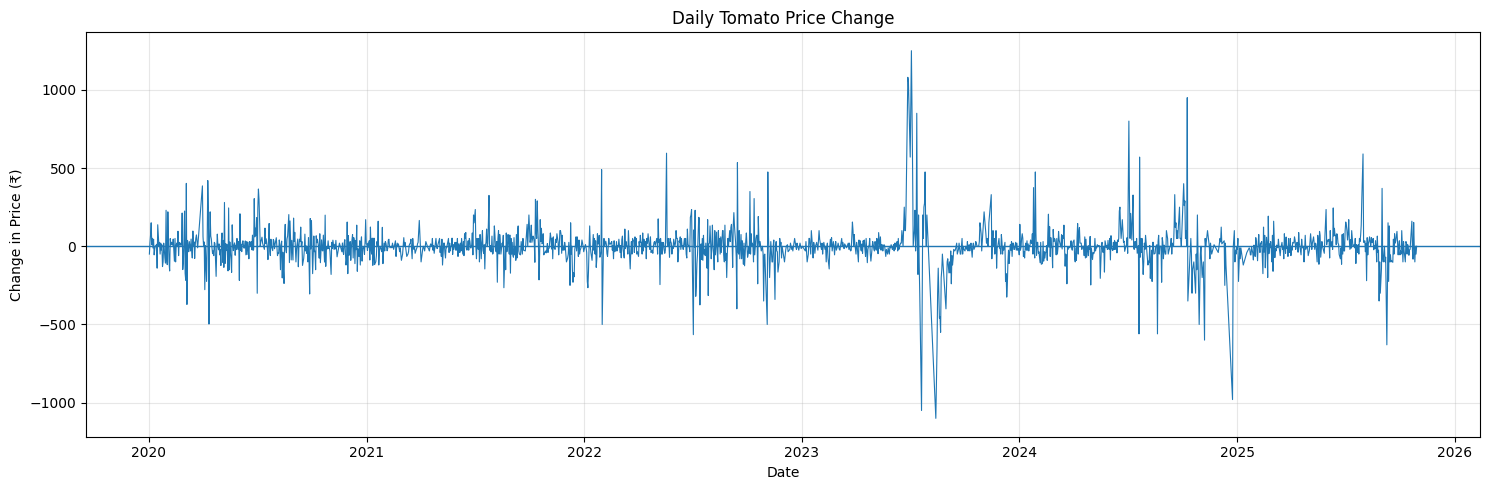

In [26]:
plt.figure(figsize=(15, 5))
plt.plot(
    df["date"],
    df["price_change"],
    linewidth=0.8
)

plt.axhline(
    0,
    linewidth=1
)
plt.title("Daily Tomato Price Change")
plt.xlabel("Date")
plt.ylabel("Change in Price (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
df_full["missing"] = df_full["price"].isna()

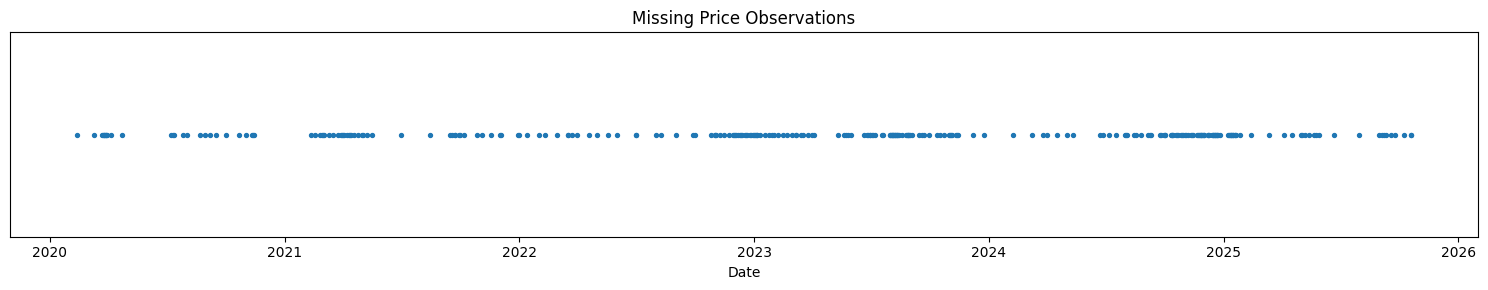

In [28]:
plt.figure(figsize=(15, 3))
plt.scatter(
    df_full.loc[df_full["missing"], "date"],
    np.ones(df_full["missing"].sum()),
    s=8
)
plt.title("Missing Price Observations")
plt.xlabel("Date")
plt.yticks([])

plt.tight_layout()
plt.show()